## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42

## 2. Load the Dataset



In [ ]:
# Path to the dataset on Colab
data_path = "/content/1) iris.csv"

df = pd.read_csv(data_path)

print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
print("Class distribution:\n")
print(df['species'].value_counts())

Class distribution:

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Exploratory Data Analysis

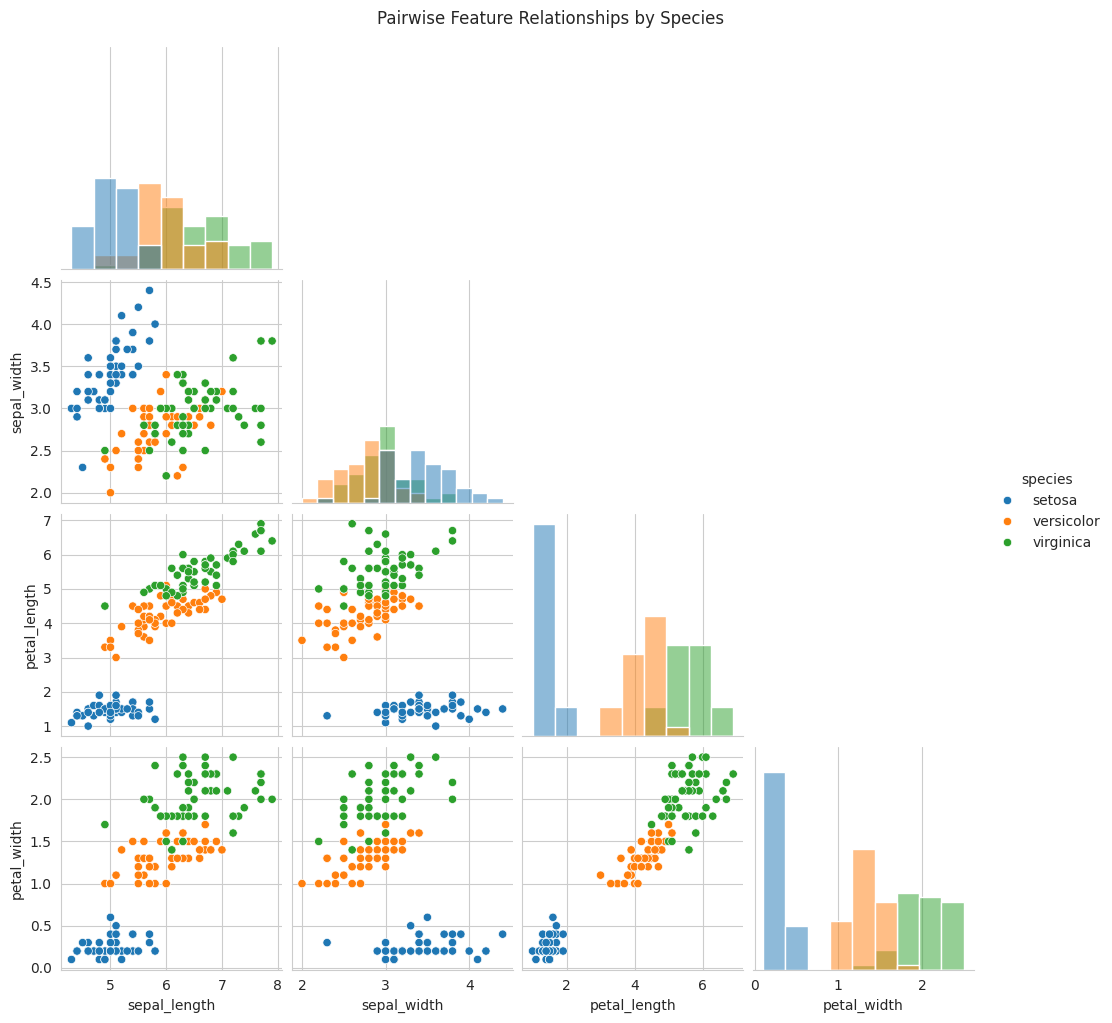

In [ ]:
sns.pairplot(df, hue='species', diag_kind='hist', corner=True)
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()

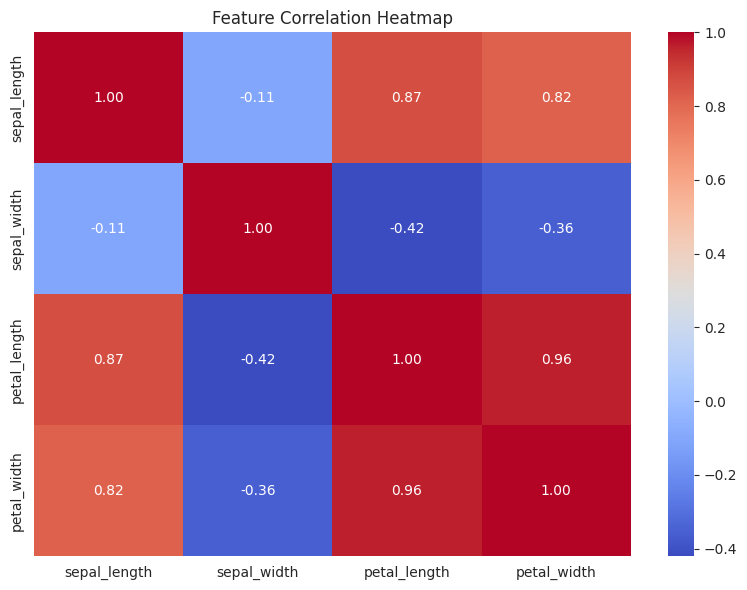

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=['species']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [ ]:
# Check for missing values and duplicates
print("Missing values per column:\n")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

Missing values per column:

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Number of duplicate rows: 3


In [ ]:
# Encode the categorical target into numeric labels
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

class_names = le.classes_
print("Class mapping:")
for i, name in enumerate(class_names):
    print(f"  {i} -> {name}")

Class mapping:
  0 -> setosa
  1 -> versicolor
  2 -> virginica


In [ ]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
target_col = 'species_encoded'

X = df[feature_cols]
y = df[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


## 5. Train/Test Split



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (120, 4)
Testing set size: (30, 4)


## 6. Train a Baseline (Unpruned) Decision Tree




In [ ]:
baseline_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, baseline_tree.predict(X_train))
test_acc = accuracy_score(y_test, baseline_tree.predict(X_test))

print(f"Baseline tree depth: {baseline_tree.get_depth()}")
print(f"Baseline tree leaves: {baseline_tree.get_n_leaves()}")
print(f"Training accuracy: {train_acc:.4f}")
print(f"Testing accuracy:  {test_acc:.4f}")

Baseline tree depth: 5
Baseline tree leaves: 8
Training accuracy: 1.0000
Testing accuracy:  0.9333


## 7. Visualize the (Unpruned) Tree Structure

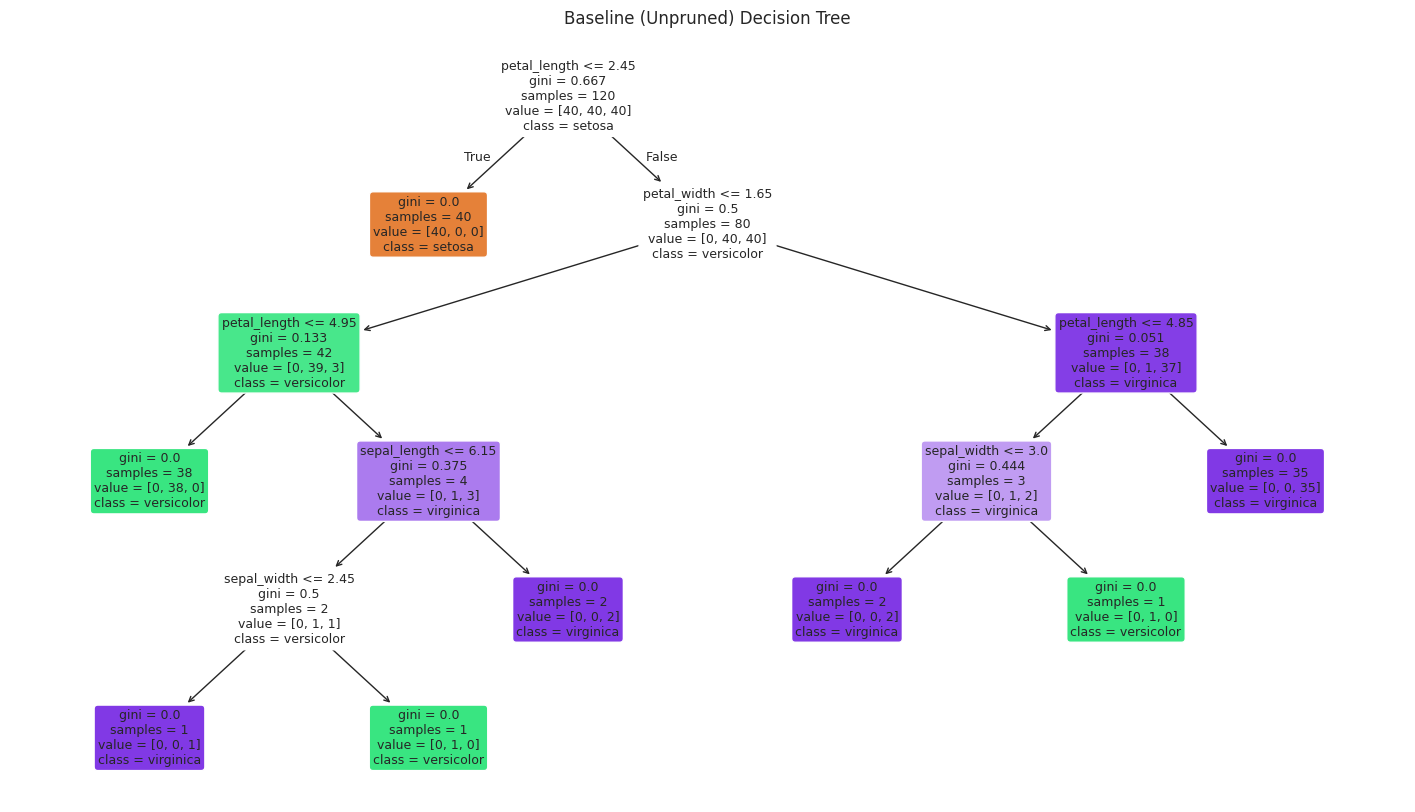

In [ ]:
plt.figure(figsize=(18, 10))
plot_tree(
    baseline_tree,
    feature_names=feature_cols,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Baseline (Unpruned) Decision Tree')
plt.show()

## 8. Pruning the Tree to Prevent Overfitting



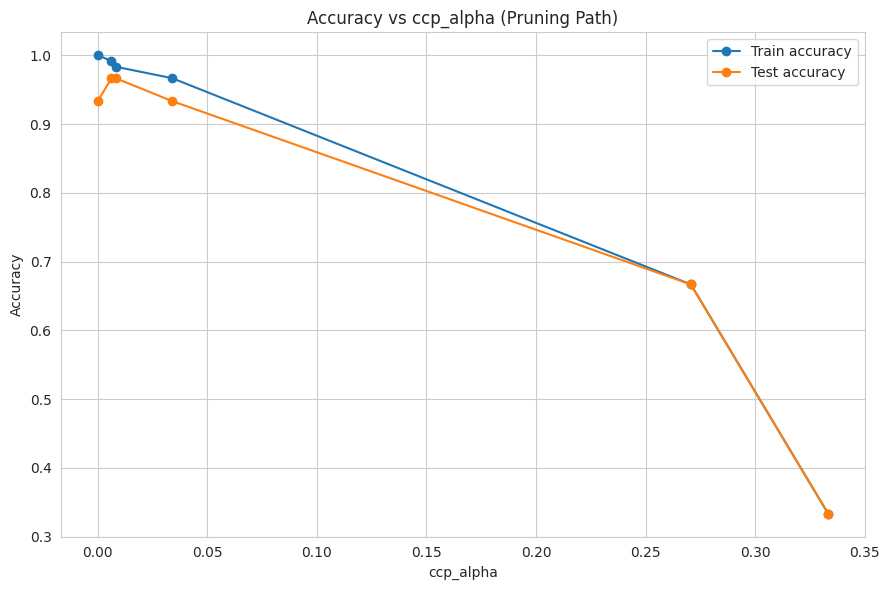

In [ ]:
# Compute the cost-complexity pruning path on the training data
path = baseline_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train accuracy')
plt.plot(ccp_alphas, test_scores, marker='o', label='Test accuracy')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs ccp_alpha (Pruning Path)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Use GridSearchCV with cross-validation to pick the best hyperparameters
param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_leaf': [1, 2, 4, 6],
    'ccp_alpha': ccp_alphas
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters found: {'ccp_alpha': np.float64(0.0), 'max_depth': 4, 'min_samples_leaf': 1}
Best cross-validation accuracy: 0.9417


In [ ]:
pruned_tree = grid_search.best_estimator_

train_acc_pruned = accuracy_score(y_train, pruned_tree.predict(X_train))
test_acc_pruned = accuracy_score(y_test, pruned_tree.predict(X_test))

print(f"Pruned tree depth: {pruned_tree.get_depth()}")
print(f"Pruned tree leaves: {pruned_tree.get_n_leaves()}")
print(f"Training accuracy: {train_acc_pruned:.4f}")
print(f"Testing accuracy:  {test_acc_pruned:.4f}")

Pruned tree depth: 4
Pruned tree leaves: 7
Training accuracy: 0.9917
Testing accuracy:  0.9333


## 9. Visualize the Pruned Tree Structure

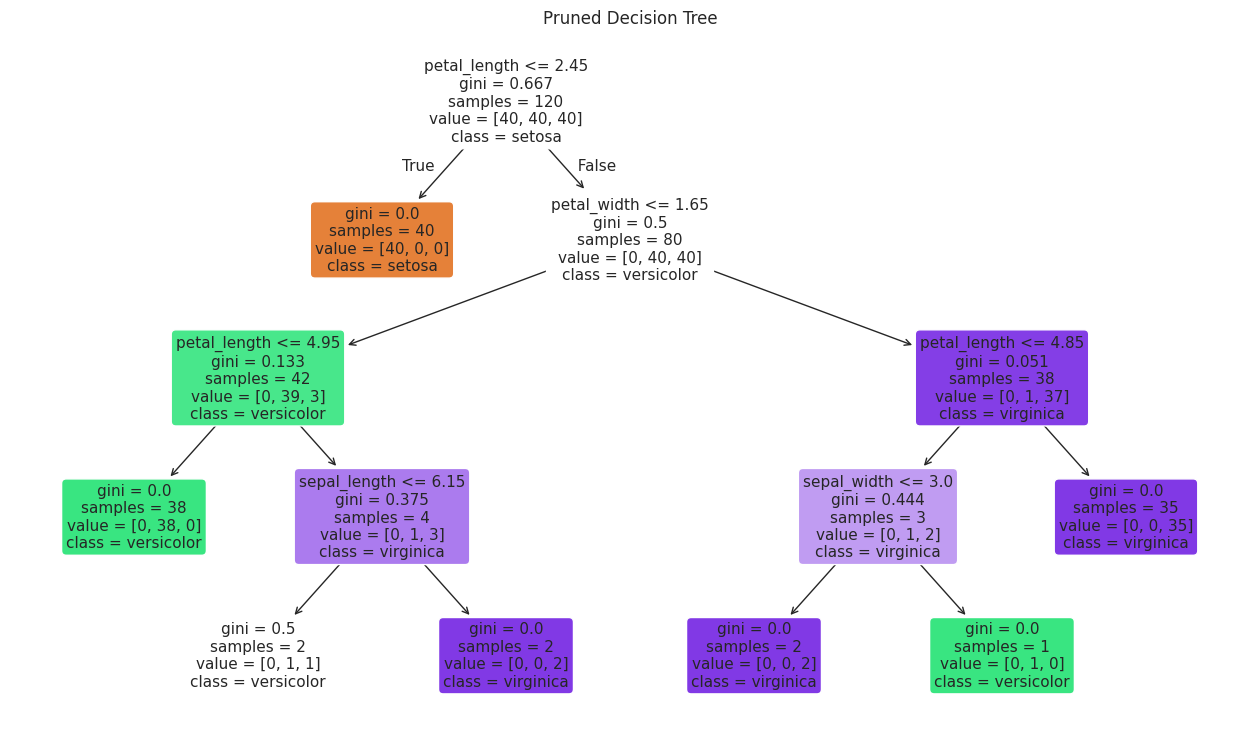

In [ ]:
plt.figure(figsize=(16, 9))
plot_tree(
    pruned_tree,
    feature_names=feature_cols,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title('Pruned Decision Tree')
plt.show()

### Baseline vs Pruned Tree Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Baseline (Unpruned)', 'Pruned'],
    'Depth': [baseline_tree.get_depth(), pruned_tree.get_depth()],
    'Leaves': [baseline_tree.get_n_leaves(), pruned_tree.get_n_leaves()],
    'Train Accuracy': [train_acc, train_acc_pruned],
    'Test Accuracy': [test_acc, test_acc_pruned]
})
comparison

,Model,Depth,Leaves,Train Accuracy,Test Accuracy
0,Baseline (Unpruned),5,8,1.000000,0.933333
1,Pruned,4,7,0.991667,0.933333


## 10. Feature Importance

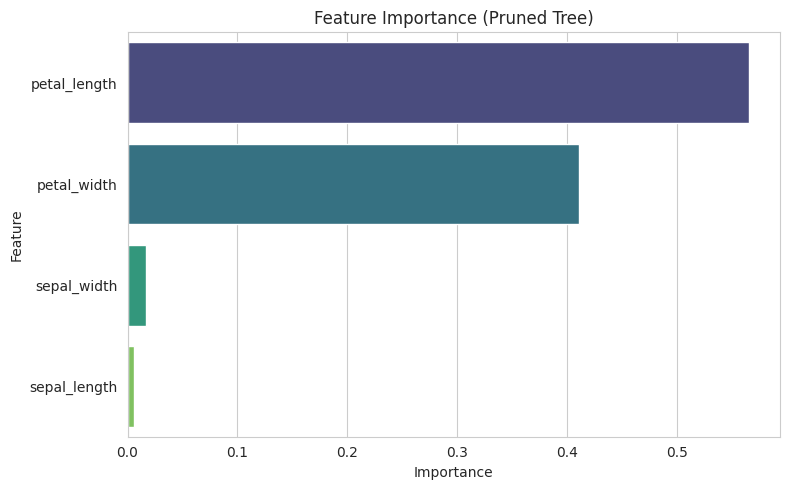

,Feature,Importance
2,petal_length,0.565639
3,petal_width,0.411154
1,sepal_width,0.016878
0,sepal_length,0.006329


In [ ]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': pruned_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance (Pruned Tree)')
plt.tight_layout()
plt.show()

importance_df

## 11. Model Evaluation



In [ ]:
y_pred = pruned_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision (macro):  {precision:.4f}")
print(f"Recall (macro):     {recall:.4f}")
print(f"F1-score (macro):   {f1:.4f}")

Accuracy:           0.9333
Precision (macro):  0.9333
Recall (macro):     0.9333
F1-score (macro):   0.9333


In [ ]:
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Full Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



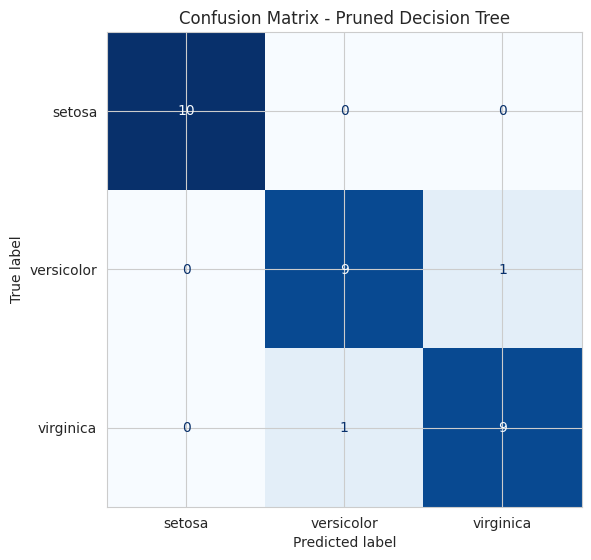

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Pruned Decision Tree')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-validated accuracy for a more robust estimate of generalization performance
cv_scores = cross_val_score(pruned_tree, X, y, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Accuracy Scores:", np.round(cv_scores, 4))
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold Cross-Validation Accuracy Scores: [0.9667 0.9667 0.9    0.9333 1.    ]
Mean CV Accuracy: 0.9533 (+/- 0.0340)
